# NB12 — Calibración post-hoc (Platt e isotónica)

**TFM · Máster Universitario en Inteligencia Artificial · VIU 2025-2026 · Víctor Rodríguez Rodríguez**

---

## Propósito
Aplicar técnicas de calibración post-hoc a los dos modelos finales, con el objetivo de mejorar la fiabilidad de las probabilidades emitidas sin alterar la capacidad discriminativa (AUC):

1. `M_A_22 + xgb` agregado a estudio - modelo final recomendado (AUC E = 0,689). Calibración base mediocre (Brier=0,140, ECE=0,260): hay margen amplio para mejorar.
2. `M_A_gg + mlp` a nivel mama - mejor AUC global a nivel mama (0,687). Calibración base muy pobre (Brier=0,194, ECE=0,381): el caso donde más impacto tendrá la calibración post-hoc.

**Inputs**: `outputs/Predicciones/M_A_22__xgb_oof.npy`, `_test.npy`; `outputs/Predicciones/M_A_gg__mlp_oof.npy`, `_test.npy`; `outputs/Features/metadata.csv`.

**Outputs**: en `outputs/Predicciones/`: `calibracion_resultados.csv`, `calibracion_tabla_memoria.csv`, `calibracion_reliability.png`; `calibracion_predicciones/{candidato}__{metodo}_test.npy`.

---

## Métodos

- **Platt scaling**: ajuste de una regresión logística sobre las probabilidades, equivalente a `p_cal = sigmoid(a * p_orig + b)`. Asume relación sigmoidal entre el score original y la probabilidad verdadera. Apropiado para distorsiones suaves típicas de SVM/MLP.
- **Isotonic regression**: ajuste no-paramétrico que solo asume monotonía. Más flexible pero requiere más datos (potencialmente sobreajusta con n pequeño).

## Diseño

- Ajustar calibrador sobre las predicciones OOF del training pool (3999 estudios o 7998 mamas, según candidato). Sin fuga porque las OOF se generaron con StratifiedGroupKFold.
- Aplicar a las predicciones test (1000 estudios o 2000 mamas).
- Verificar: AUC no cambia significativamente (DeLong), Brier y ECE mejoran.
- Visualizar con reliability diagrams antes/después.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

BASE = os.environ.get('TFM_PROJECT_ROOT', os.path.abspath(os.path.join(os.getcwd(), '..')))
OUTPUTS = os.path.join(BASE, 'outputs')
FEATURES_DIR = os.path.join(OUTPUTS, 'Features')
PRED_DIR_V2 = os.path.join(OUTPUTS, 'Predicciones')
CALIB_DIR = os.path.join(PRED_DIR_V2, 'calibracion_predicciones')
NB_DIR = os.path.join(BASE, 'src')

os.makedirs(CALIB_DIR, exist_ok=True)
sys.path.insert(0, NB_DIR)
from tfm_eval import ( delong_test, aggregate_breast_to_study, compute_full_metrics, SEED)

np.random.seed(SEED)
print(f'CALIB_DIR: {CALIB_DIR}')

CALIB_DIR: c:\Users\victo\Documents\TFM\Proyecto\outputs\Predicciones\calibracion_predicciones


## 1. Cargar metadata, etiquetas y predicciones de los candidatos

In [2]:
meta = pd.read_csv(os.path.join(FEATURES_DIR, 'metadata.csv'))
N = len(meta)
is_train_E = (meta['split'].values == 'training')
is_test_E = (meta['split'].values == 'test')

# Nivel estudio
y_E_train = meta['y_estudio'].values[is_train_E].astype(int)
y_E_test = meta['y_estudio'].values[is_test_E].astype(int)
study_ids_E_train = meta['study_id'].values[is_train_E]
study_ids_E_test = meta['study_id'].values[is_test_E]

# Nivel mama
y_M = np.concatenate([meta['y_L'].values, meta['y_R'].values]).astype(int)
split_M = np.concatenate([meta['split'].values, meta['split'].values])
y_M_train = y_M[split_M == 'training']
y_M_test = y_M[split_M == 'test']

# Cargar candidatos
CANDIDATOS = [
    {
        'nombre': 'M_A_22__xgb_agg_E',
        'pred_file': 'M_A_22__xgb',
        'nivel': 'estudio',
        'descripcion': 'XGBoost sobre vista 2x2 a nivel mama, agregado a estudio (max L,R) — MODELO FINAL CLÍNICO',
    },
    {
        'nombre': 'M_A_gg__mlp_mama',
        'pred_file': 'M_A_gg__mlp',
        'nivel': 'mama',
        'descripcion': 'MLP sobre vista GAP+GMP a nivel mama (mejor AUC mama, peor calibrado)',
    },
]

# Cargar y preparar predicciones (OOF y test) para cada candidato
for c in CANDIDATOS:
    pred_M_oof  = np.load(os.path.join(PRED_DIR_V2, f'{c["pred_file"]}_oof.npy'))
    pred_M_test = np.load(os.path.join(PRED_DIR_V2, f'{c["pred_file"]}_test.npy'))
    if c['nivel'] == 'estudio':
        c['pred_oof'],  _ = aggregate_breast_to_study(pred_M_oof,  study_ids_E_train, agg='max')
        c['pred_test'], _ = aggregate_breast_to_study(pred_M_test, study_ids_E_test,  agg='max')
        c['y_train'] = y_E_train
        c['y_test'] = y_E_test
    else:
        c['pred_oof'] = pred_M_oof
        c['pred_test'] = pred_M_test
        c['y_train'] = y_M_train
        c['y_test'] = y_M_test
    print(f'{c["nombre"]:<22s} ({c["nivel"]:7s}) OOF={c["pred_oof"].shape} test={c["pred_test"].shape}')
    print(f'{c["descripcion"]}')

M_A_22__xgb_agg_E      (estudio) OOF=(3999,) test=(1000,)
XGBoost sobre vista 2x2 a nivel mama, agregado a estudio (max L,R) — MODELO FINAL CLÍNICO
M_A_gg__mlp_mama       (mama   ) OOF=(7998,) test=(2000,)
MLP sobre vista GAP+GMP a nivel mama (mejor AUC mama, peor calibrado)


## 2. Funciones de calibración post-hoc

In [3]:
def platt_calibrate(p_oof, y_oof, p_test):
    clf = LogisticRegression(C=1e8, solver='lbfgs', max_iter=1000) 
    clf.fit(p_oof.reshape(-1, 1), y_oof)
    a, b = float(clf.coef_[0, 0]), float(clf.intercept_[0])
    p_cal_test = clf.predict_proba(p_test.reshape(-1, 1))[:, 1]
    return p_cal_test, {'a': a, 'b': b}

def isotonic_calibrate(p_oof, y_oof, p_test):
    iso = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
    iso.fit(p_oof, y_oof)
    return iso.transform(p_test), {'n_breakpoints': len(iso.X_thresholds_)}

# Test con datos sintéticos
rng = np.random.RandomState(42)
p_test_synth = rng.beta(2, 5, 500)
y_test_synth = (p_test_synth > 0.3).astype(int)
p_cal_p, info_p = platt_calibrate(p_test_synth[:300], y_test_synth[:300], p_test_synth[300:])
p_cal_i, info_i = isotonic_calibrate(p_test_synth[:300], y_test_synth[:300], p_test_synth[300:])
print(f'Platt: a={info_p["a"]:.3f} b={info_p["b"]:.3f} output rango=[{p_cal_p.min():.3f}, {p_cal_p.max():.3f}]')
print(f'Isotonic: n_breakpoints={info_i["n_breakpoints"]} output rango=[{p_cal_i.min():.3f}, {p_cal_i.max():.3f}]')

Platt: a=2055.853 b=-617.853 output rango=[0.000, 1.000]
Isotonic: n_breakpoints=4 output rango=[0.000, 1.000]


## 3. Aplicar calibración a cada candidato

Aplicamos Platt e isotónica sobre cada candidato y guardamos las predicciones calibradas + métricas completas.

In [4]:
results_rows = []
all_calibrated = {}

for c in CANDIDATOS:
    nombre = c['nombre']
    p_oof, p_test = c['pred_oof'], c['pred_test']
    y_train, y_test = c['y_train'], c['y_test']
    
    # BASE (sin calibrar)
    m_base = compute_full_metrics(y_test, p_test, n_boot=1000)
    results_rows.append({'candidato': nombre, 'nivel': c['nivel'], 'metodo': 'base', **m_base})
    all_calibrated[f'{nombre}__base'] = p_test
    
    # PLATT
    p_test_platt, info_platt = platt_calibrate(p_oof, y_train, p_test)
    m_platt = compute_full_metrics(y_test, p_test_platt, n_boot=1000)
    delong_platt = delong_test(y_test, p_test_platt, p_test)
    results_rows.append({'candidato': nombre, 'nivel': c['nivel'], 'metodo': 'platt', **m_platt, 'delta_auc_vs_base': delong_platt['delta'], 'p_delong_vs_base': delong_platt['p_value']})
    all_calibrated[f'{nombre}__platt'] = p_test_platt
    np.save(os.path.join(CALIB_DIR, f'{nombre}__platt_test.npy'), p_test_platt)
    
    # ISOTONIC
    p_test_iso, info_iso = isotonic_calibrate(p_oof, y_train, p_test)
    m_iso = compute_full_metrics(y_test, p_test_iso, n_boot=1000)
    delong_iso = delong_test(y_test, p_test_iso, p_test)
    results_rows.append({'candidato': nombre, 'nivel': c['nivel'], 'metodo': 'isotonic', **m_iso, 'delta_auc_vs_base': delong_iso['delta'], 'p_delong_vs_base': delong_iso['p_value']})
    all_calibrated[f'{nombre}__isotonic'] = p_test_iso
    np.save(os.path.join(CALIB_DIR, f'{nombre}__isotonic_test.npy'), p_test_iso)
    
    print(f'\n{nombre}:')
    print(f'Platt: a={info_platt["a"]:.3f} b={info_platt["b"]:.3f}')
    print(f'Isotonic: {info_iso["n_breakpoints"]} breakpoints')

df_cal = pd.DataFrame(results_rows)
df_cal.to_csv(os.path.join(PRED_DIR_V2, 'calibracion_resultados.csv'), index=False)
print(f'\nTabla guardada en calibracion_resultados.csv ({len(df_cal)} filas)')


M_A_22__xgb_agg_E:
Platt: a=3.125 b=-3.501
Isotonic: 40 breakpoints

M_A_gg__mlp_mama:
Platt: a=3.838 b=-4.783
Isotonic: 44 breakpoints

Tabla guardada en calibracion_resultados.csv (6 filas)


## 4. Tabla comparativa antes/después

In [5]:
for c in CANDIDATOS:
    nombre = c['nombre']
    sub = df_cal[df_cal['candidato'] == nombre]

    print(f' {nombre}  ({c["nivel"]})')
    print('-' * 100)
    print(f'{"Método":<12s} {"AUC [IC95%]":<26s} {"AP":<10s} {"Brier":<10s} {"ECE":<10s} {"Δ AUC":<10s} {"p_DeLong":<10s}')
    for _, r in sub.iterrows():
        delta_auc = r.get('delta_auc_vs_base', np.nan)
        p_val = r.get('p_delong_vs_base', np.nan)
        delta_str = f'{delta_auc:+.4f}' if not pd.isna(delta_auc) else '-'
        p_str = f'{p_val:.4f}' if not pd.isna(p_val) else '   -    '
        print(f'{r["metodo"]:<10s}  {r["auc"]:.4f} [{r["auc_lo"]:.4f},{r["auc_hi"]:.4f}]    {r["ap"]:.4f}       {r["brier"]:.4f}     {r["ece"]:.4f}    {delta_str:<10s} {p_str}')
    
    # Cálculo de mejoras relativas
    base_row = sub[sub.metodo == 'base'].iloc[0]
    print(f'\nMejoras relativas (vs base):')
    for met in ['platt', 'isotonic']:
        m_row = sub[sub.metodo == met].iloc[0]
        brier_red = 100 * (base_row['brier'] - m_row['brier']) / base_row['brier']
        ece_red = 100 * (base_row['ece'] - m_row['ece']) / base_row['ece']
        print(f'{met:8s}: Brier -{brier_red:5.1f}%   ECE -{ece_red:5.1f}%')
    print()

 M_A_22__xgb_agg_E  (estudio)
----------------------------------------------------------------------------------------------------
Método       AUC [IC95%]                AP         Brier      ECE        Δ AUC      p_DeLong  
base        0.6891 [0.6282,0.7479]    0.3632       0.1403     0.2599    -             -    
platt       0.6891 [0.6282,0.7479]    0.3632       0.0802     0.0193    +0.0000    1.0000
isotonic    0.6347 [0.5874,0.6855]    0.3131       0.0743     0.0182    -0.0544    0.0099

Mejoras relativas (vs base):
platt   : Brier - 42.8%   ECE - 92.6%
isotonic: Brier - 47.1%   ECE - 93.0%

 M_A_gg__mlp_mama  (mama)
----------------------------------------------------------------------------------------------------
Método       AUC [IC95%]                AP         Brier      ECE        Δ AUC      p_DeLong  
base        0.6866 [0.6289,0.7417]    0.2422       0.1943     0.3811    -             -    
platt       0.6866 [0.6289,0.7417]    0.2422       0.0442     0.0080    +0.0000  

## 5. Reliability diagrams

Las curvas de fiabilidad muestran, para cada bin de probabilidad predicha, la fracción real de positivos observada. La diagonal es la calibración perfecta.

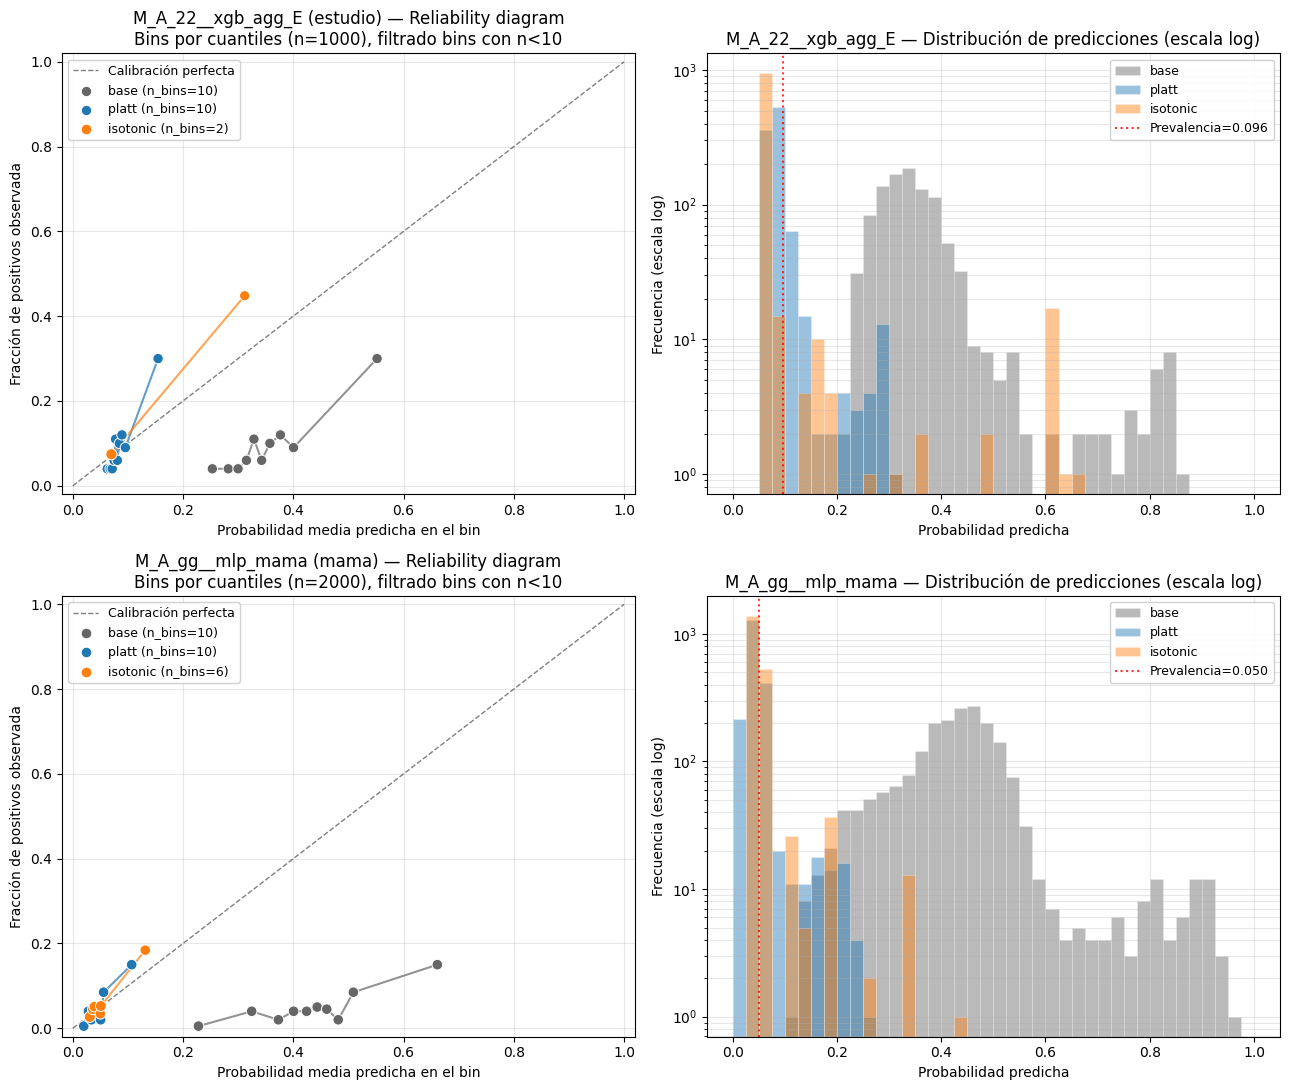

Guardado: calibracion_reliability.png (versión mejorada)
- Binning por cuantiles (10 cuantiles)
- Bins con n<10 muestras filtrados
- Marcadores proporcionales al tamaño del bin
- Histograma con escala log en Y


In [6]:
def reliability_data_quantile(y_true, y_pred, n_bins=10, min_n_bin=10):
    # Cuantiles de las predicciones para definir bordes de bin
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_pred, quantiles)
    edges = np.unique(edges)  # eliminar duplicados
    if len(edges) < 2:
        return np.array([]), np.array([]), np.array([])
    
    means_pred, frac_pos, counts = [], [], []
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i+1]
        if i == 0:
            mask = (y_pred >= lo) & (y_pred <= hi)
        else:
            mask = (y_pred > lo) & (y_pred <= hi)
        n = mask.sum()
        if n < min_n_bin:
            continue
        means_pred.append(y_pred[mask].mean())
        frac_pos.append(y_true[mask].mean())
        counts.append(n)
    return np.array(means_pred), np.array(frac_pos), np.array(counts)


fig, axes = plt.subplots(2, 2, figsize=(13, 11))
colors = {'base': '#666666', 'platt': '#1f77b4', 'isotonic': '#ff7f0e'}
N_BINS_QUANTILE = 10
MIN_N_BIN = 10

for row_idx, c in enumerate(CANDIDATOS):
    nombre = c['nombre']
    y_test = c['y_test']
    n_test = len(y_test)
    
    ax = axes[row_idx, 0]
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibración perfecta', linewidth=1)
    for met in ['base', 'platt', 'isotonic']:
        p_test = all_calibrated[f'{nombre}__{met}']
        m, f, n = reliability_data_quantile(y_test, p_test, n_bins=N_BINS_QUANTILE, min_n_bin=MIN_N_BIN)
        if len(m) == 0:
            continue
        # Línea continua entre puntos + marcadores proporcionales a n
        ax.plot(m, f, '-', color=colors[met], linewidth=1.5, alpha=0.7)
        # Tamaño del marcador proporcional al log del conteo, mínimo razonable
        sizes = 40 + 8 * np.log10(np.maximum(n, 1) + 1)
        ax.scatter(m, f, s=sizes, color=colors[met], edgecolors='white', linewidth=0.7, label=f'{met} (n_bins={len(m)})', zorder=3)
    
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('Probabilidad media predicha en el bin')
    ax.set_ylabel('Fracción de positivos observada')
    ax.set_title(f'{nombre} ({c["nivel"]}) — Reliability diagram\n' f'Bins por cuantiles (n={n_test}), filtrado bins con n<{MIN_N_BIN}')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.3)
    
    ax = axes[row_idx, 1]
    bin_edges = np.linspace(0, 1, 41)  # 40 bins para más resolución
    for met in ['base', 'platt', 'isotonic']:
        p_test = all_calibrated[f'{nombre}__{met}']
        ax.hist(p_test, bins=bin_edges, alpha=0.45, color=colors[met], label=met, edgecolor='white', linewidth=0.4)
    prev = y_test.mean()
    ax.axvline(prev, color='red', linestyle=':', alpha=0.8, linewidth=1.5, label=f'Prevalencia={prev:.3f}')
    ax.set_yscale('log')
    ax.set_xlabel('Probabilidad predicha')
    ax.set_ylabel('Frecuencia (escala log)')
    ax.set_title(f'{nombre} — Distribución de predicciones (escala log)')
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'calibracion_reliability.png'), dpi=140, bbox_inches='tight')
plt.show()
print('Guardado: calibracion_reliability.png (versión mejorada)')
print(f'- Binning por cuantiles ({N_BINS_QUANTILE} cuantiles)')
print(f'- Bins con n<{MIN_N_BIN} muestras filtrados')
print(f'- Marcadores proporcionales al tamaño del bin')
print(f'- Histograma con escala log en Y')

## 6. Análisis adicional: tabla compacta con métricas y mejoras

In [7]:
rows_tabla = []
for c in CANDIDATOS:
    nombre = c['nombre']
    sub = df_cal[df_cal['candidato'] == nombre]
    base = sub[sub.metodo == 'base'].iloc[0]
    for met in ['platt', 'isotonic']:
        m = sub[sub.metodo == met].iloc[0]
        rows_tabla.append({
            'Candidato': nombre,
            'Método': met,
            'AUC base': f'{base["auc"]:.4f}',
            'AUC calibrado': f'{m["auc"]:.4f} ({m["delta_auc_vs_base"]:+.4f})',
            'p_DeLong AUC': f'{m["p_delong_vs_base"]:.3f}',
            'Brier base': f'{base["brier"]:.4f}',
            'Brier cal': f'{m["brier"]:.4f} (-{100*(base["brier"]-m["brier"])/base["brier"]:.1f}%)',
            'ECE base': f'{base["ece"]:.4f}',
            'ECE cal': f'{m["ece"]:.4f} (-{100*(base["ece"]-m["ece"])/base["ece"]:.1f}%)',
        })

df_tabla = pd.DataFrame(rows_tabla)
print(df_tabla.to_string(index=False))
df_tabla.to_csv(os.path.join(PRED_DIR_V2, 'calibracion_tabla_memoria.csv'), index=False)

        Candidato   Método AUC base    AUC calibrado p_DeLong AUC Brier base       Brier cal ECE base         ECE cal
M_A_22__xgb_agg_E    platt   0.6891 0.6891 (+0.0000)        1.000     0.1403 0.0802 (-42.8%)   0.2599 0.0193 (-92.6%)
M_A_22__xgb_agg_E isotonic   0.6891 0.6347 (-0.0544)        0.010     0.1403 0.0743 (-47.1%)   0.2599 0.0182 (-93.0%)
 M_A_gg__mlp_mama    platt   0.6866 0.6866 (+0.0000)        1.000     0.1943 0.0442 (-77.3%)   0.3811 0.0080 (-97.9%)
 M_A_gg__mlp_mama isotonic   0.6866 0.6718 (-0.0148)        0.001     0.1943 0.0436 (-77.6%)   0.3811 0.0051 (-98.7%)


## 7. Resumen

In [8]:
ALPHA_AUC = 0.05  # umbral

for c in CANDIDATOS:
    nombre = c['nombre']
    sub = df_cal[df_cal['candidato'] == nombre]
    base = sub[sub.metodo == 'base'].iloc[0]
    platt = sub[sub.metodo == 'platt'].iloc[0]
    iso = sub[sub.metodo == 'isotonic'].iloc[0]
    
    print(f'\n{nombre} ({c["nivel"]}):')
    print(f'AUC: base={base["auc"]:.4f} platt={platt["auc"]:.4f} (p_DeLong={platt["p_delong_vs_base"]:.3f}) isotonic={iso["auc"]:.4f} (p_DeLong={iso["p_delong_vs_base"]:.3f})')
    print(f'Brier: base={base["brier"]:.4f} platt={platt["brier"]:.4f} isotonic={iso["brier"]:.4f}')
    print(f'ECE: base={base["ece"]:.4f} platt={platt["ece"]:.4f} isotonic={iso["ece"]:.4f}')
    
    candidatos_metodo = [('platt', platt), ('isotonic', iso)]
    admisibles = [(nm, row) for nm, row in candidatos_metodo if row['p_delong_vs_base'] > ALPHA_AUC]
    
    if len(admisibles) == 0:
        print(f'Ningún método preserva AUC (todas las p_DeLong < {ALPHA_AUC}).')
        print(f'Recomendación: mantener BASE sin calibrar para preservar discriminación,')
        print(f'o aceptar la pérdida de AUC si la calibración es prioritaria.')
    else:
        # Entre los admisibles, el de menor ECE gana
        admisibles.sort(key=lambda x: x[1]['ece'])
        rec_nombre, rec_row = admisibles[0]
        descartados = [(nm, r) for nm, r in candidatos_metodo if r['p_delong_vs_base'] <= ALPHA_AUC]
        descartado_str = '' if not descartados else f' (descartado: {descartados[0][0]} por pérdida significativa de AUC, p={descartados[0][1]["p_delong_vs_base"]:.3f})'
        print(f'Método recomendado: {rec_nombre.upper()}{descartado_str}')
        print(f'AUC={rec_row["auc"]:.4f}  Brier={rec_row["brier"]:.4f} (-{100*(base["brier"]-rec_row["brier"])/base["brier"]:.1f}%)  '
              f'ECE={rec_row["ece"]:.4f} (-{100*(base["ece"]-rec_row["ece"])/base["ece"]:.1f}%)')

print('\nArchivos generados:')
print('-' * 80)
for f in ['calibracion_resultados.csv', 'calibracion_tabla_memoria.csv', 'calibracion_reliability.png']:
    path = os.path.join(PRED_DIR_V2, f)
    exists = 'OK' if os.path.isfile(path) else 'FALTA'
    print(f'{exists} {f}')
n_files = len([f for f in os.listdir(CALIB_DIR) if f.endswith('_test.npy')])
print(f'OK calibracion_predicciones/ ({n_files} archivos *_test.npy)')


M_A_22__xgb_agg_E (estudio):
AUC: base=0.6891 platt=0.6891 (p_DeLong=1.000) isotonic=0.6347 (p_DeLong=0.010)
Brier: base=0.1403 platt=0.0802 isotonic=0.0743
ECE: base=0.2599 platt=0.0193 isotonic=0.0182
Método recomendado: PLATT (descartado: isotonic por pérdida significativa de AUC, p=0.010)
AUC=0.6891  Brier=0.0802 (-42.8%)  ECE=0.0193 (-92.6%)

M_A_gg__mlp_mama (mama):
AUC: base=0.6866 platt=0.6866 (p_DeLong=1.000) isotonic=0.6718 (p_DeLong=0.001)
Brier: base=0.1943 platt=0.0442 isotonic=0.0436
ECE: base=0.3811 platt=0.0080 isotonic=0.0051
Método recomendado: PLATT (descartado: isotonic por pérdida significativa de AUC, p=0.001)
AUC=0.6866  Brier=0.0442 (-77.3%)  ECE=0.0080 (-97.9%)

Archivos generados:
--------------------------------------------------------------------------------
OK calibracion_resultados.csv
OK calibracion_tabla_memoria.csv
OK calibracion_reliability.png
OK calibracion_predicciones/ (4 archivos *_test.npy)
